# Distribution functions

`phasegen` exposes the full distribution of any accumulated coalescent reward (tree height, total branch length, an individual SFS bin's branch length, or any {doc}`custom reward <rewards>`) as callable, plottable distribution-function objects (`pdf`, `cdf`, `quantile`). They are analytically exact, obtained by numerically inverting the reward's Laplace transform rather than by sampling, though the inversion can lose precision for extreme demographies.

```{versionadded} 2.0
```

Any two rewards additionally have a joint distribution, from which the {meth}`JointRewardDistribution.marginal <phasegen.distributions.JointRewardDistribution.marginal>` and {meth}`JointRewardDistribution.conditional <phasegen.distributions.JointRewardDistribution.conditional>` distributions of one given the other follow.

In [1]:
Sys.setenv(TQDM_DISABLE = "1")
setwd("~/PycharmProjects/PhaseGen/")
reticulate::use_condaenv("/Users/janek/miniforge3/envs/dev-phasegen", required = TRUE)

In [2]:
mpl <- reticulate::import("matplotlib")
mpl$use("Agg")
plt <- reticulate::import("matplotlib.pyplot")
plt$rcParams[["figure.figsize"]] <- c(4.4, 3.3)
options(repr.plot.width = 4.4, repr.plot.height = 3.3)

# render a phasegen plot object (calls its .plot()) inline
render <- function(obj) {
  p <- tempfile(fileext = ".png"); obj$plot(show = FALSE, file = p); IRdisplay::display_png(file = p)
}
# render an arbitrary matplotlib figure drawn by `draw`, which saves to the given path
render_fn <- function(draw) {
  p <- tempfile(fileext = ".png"); draw(p); IRdisplay::display_png(file = p)
}
# run a call and echo the phasegen log output it emits, so it is captured in the rendered cell
with_log <- function(expr) cat(reticulate::py_capture_output(expr))

In [3]:
library(phasegen)

pg <- load_phasegen()

## One-dimensional reward distributions

Take a single population through a sharp bottleneck. Its {meth}`Coalescent.total_branch_length <phasegen.distributions.Coalescent.total_branch_length>`, the summed length of every branch in the tree, is a distribution whose `pdf`, `cdf` and `quantile` are callable at points and plottable.

In [4]:
coal <- pg$Coalescent(
    n = 8L,
    demography = pg$Demography(
        pop_sizes = list(
            pop_0 = reticulate::py_dict(list(0, 0.25, 0.7), list(1.0, 0.08, 1.0))
        )
    )
)

tbl <- coal$total_branch_length

cat(sprintf("f(1.5)     = %.3f\n", tbl$pdf(1.5)))
cat(sprintf("P(L <= 2)  = %.3f\n", tbl$cdf(2.0)))
cat(sprintf("median     = %.3f\n", tbl$quantile(0.5)))

f(1.5)     = 1.022


P(L <= 2)  = 0.814


median     = 1.730


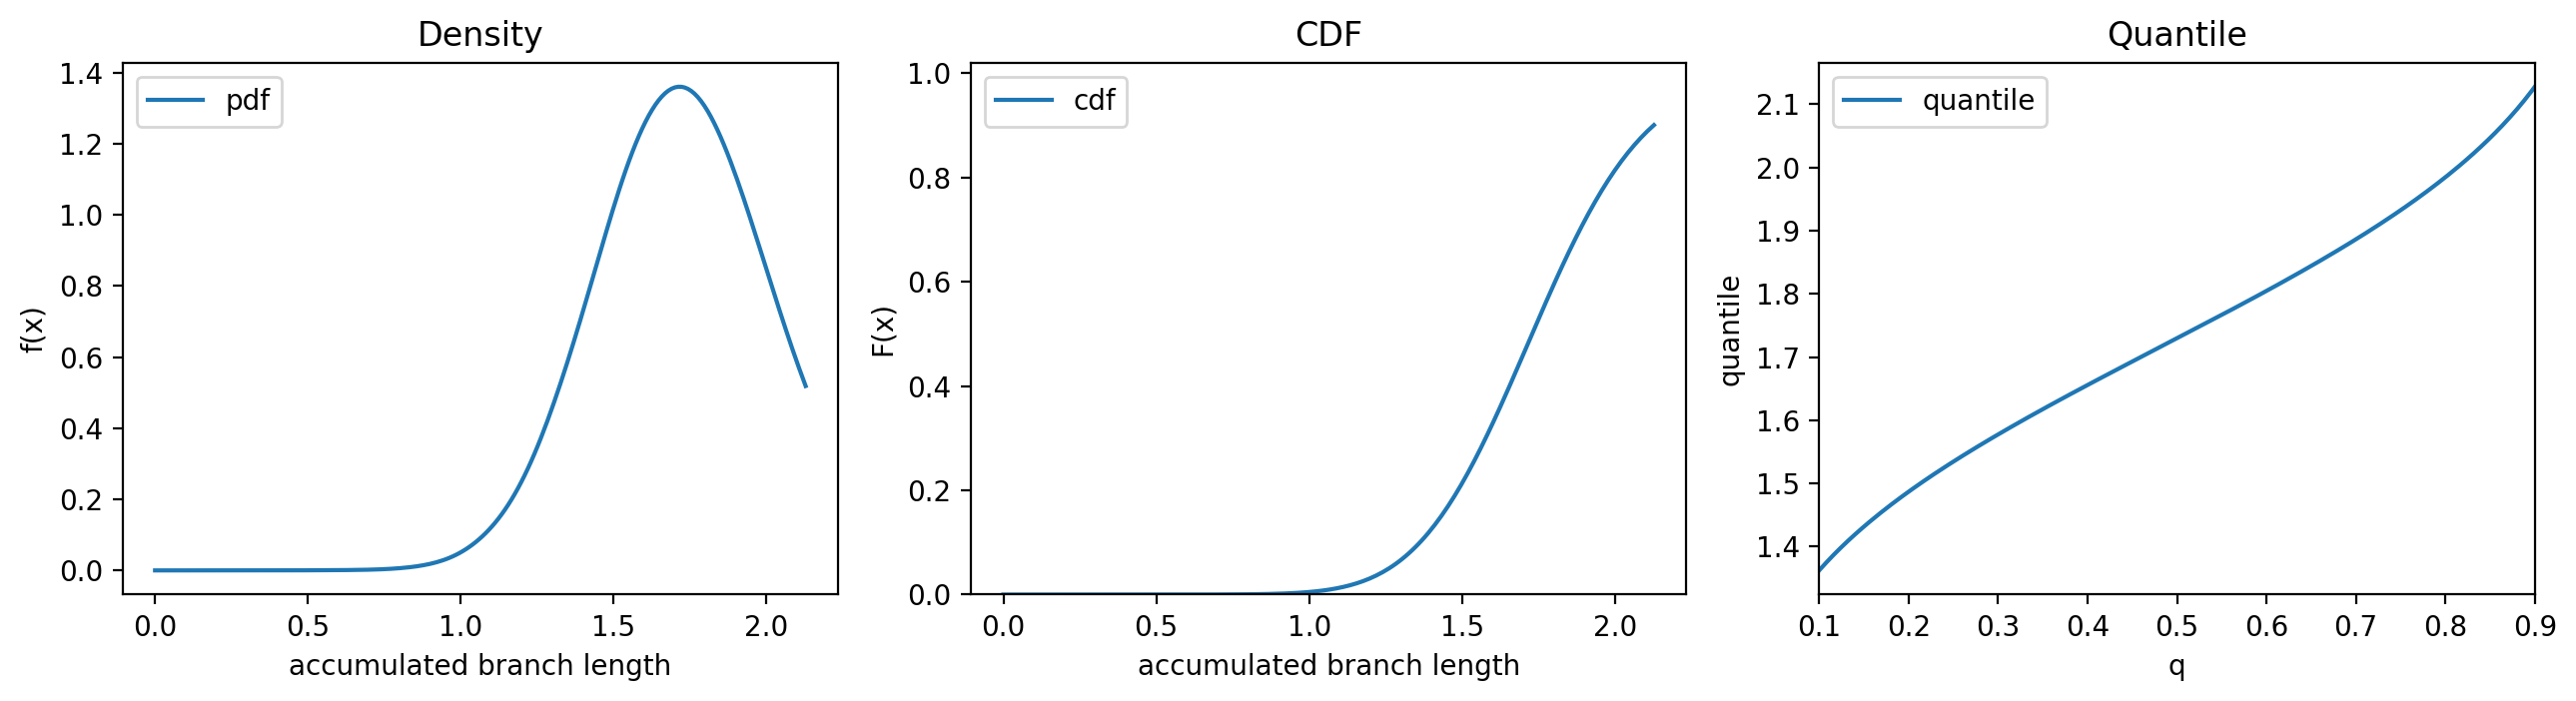

In [5]:
render_fn(function(f) {
    res <- plt$subplots(ncols = 3L, figsize = c(13, 3.6))
    axs <- res[[2]]
    tbl$pdf$plot(ax = axs[[1]], show = FALSE, title = "Density")
    tbl$cdf$plot(ax = axs[[2]], show = FALSE, title = "CDF")
    tbl$quantile$plot(ax = axs[[3]], show = FALSE, title = "Quantile")
    plt$tight_layout(); plt$savefig(f, dpi = 200, bbox_inches = "tight"); plt$close("all")
})

The `quantile` is the inverse of the `cdf`: `quantile(0.5)` is the median, `quantile(0.9)` the branch length exceeded only one time in ten.

## Joint distributions

Any two accumulated rewards have a joint distribution. {meth}`UnfoldedSFSDistribution.joint_distribution <phasegen.distributions.UnfoldedSFSDistribution.joint_distribution>` returns it as a {class}`~phasegen.distributions.JointRewardDistribution` with a 2D `pdf` and `cdf` (a joint quantile is not well-defined). As an example, take two rewards from the bottleneck above, the singleton and doubleton branch lengths (SFS bins 1 and 2). They are not independent: within a tree, branch length subtending one frequency class reduces that available to the other, so their joint distribution is bimodal and negatively correlated.

In [6]:
joint <- coal$sfs$joint_distribution(1L, 2L)  # singleton and doubleton branch lengths

cat(sprintf("P(R_a <= 1.5, R_b <= 0.5) = %.3f\n", joint$cdf(1.5, 0.5)))
cat("means (E[R_a], E[R_b])    =", paste(round(joint$mean, 3), collapse = " "), "\n")
cat(sprintf("correlation               = %.3f\n", joint$corr()))

P(R_a <= 1.5, R_b <= 0.5) = 0.694


means (E[R_a], E[R_b])    = 1.132 0.325 


correlation               = -0.307


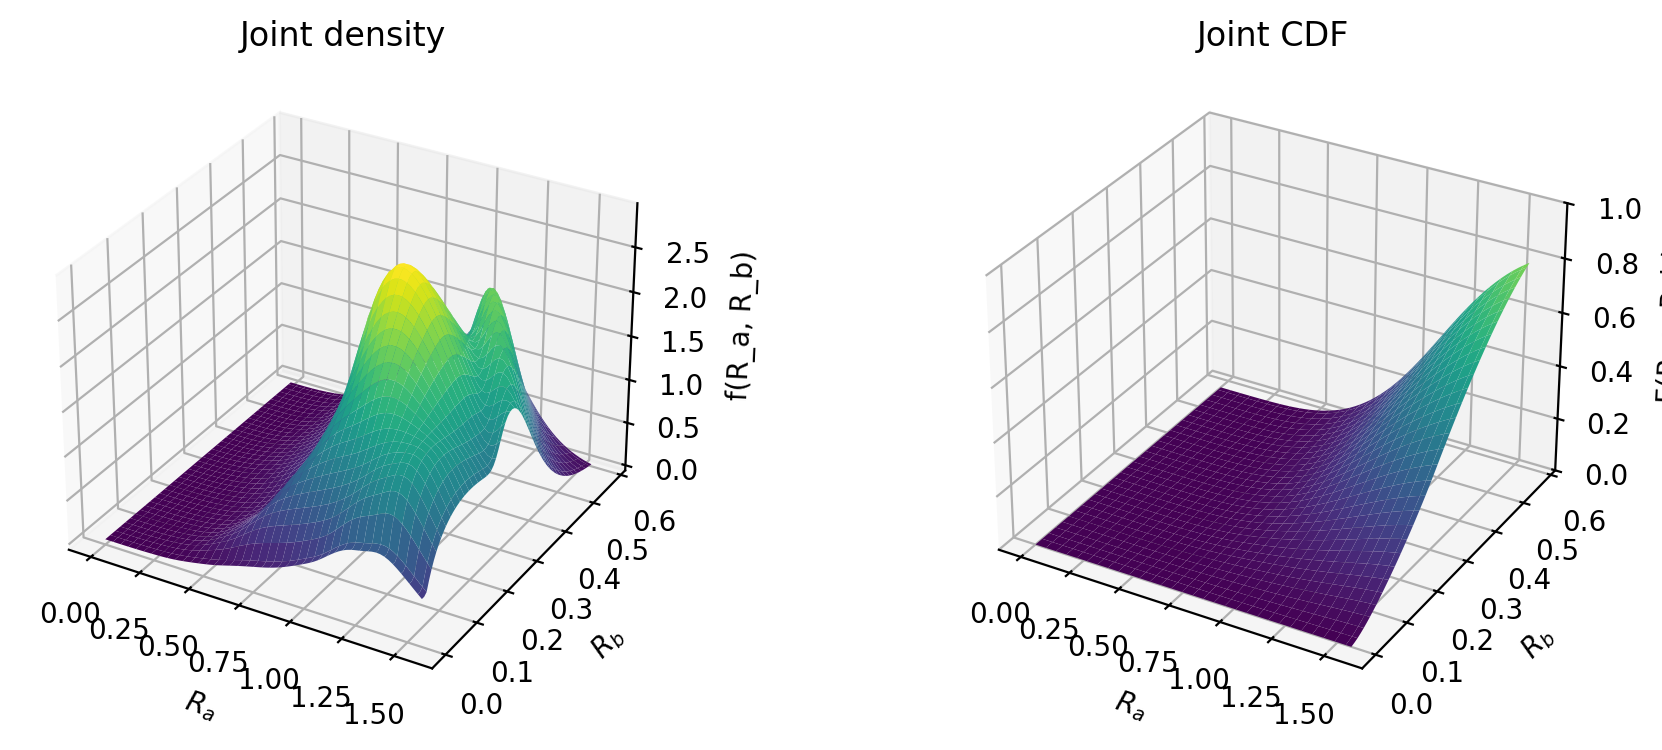

In [7]:
render_fn(function(f) {
    res <- plt$subplots(ncols = 2L, figsize = c(11, 4.2), subplot_kw = list(projection = "3d"))
    axs <- res[[2]]
    joint$pdf$plot_surface(ax = axs[[1]], show = FALSE, title = "Joint density")
    joint$cdf$plot_surface(ax = axs[[2]], show = FALSE, title = "Joint CDF")
    plt$savefig(f, dpi = 200, bbox_inches = "tight"); plt$close("all")
})

## Marginal distributions

{meth}`JointRewardDistribution.marginal <phasegen.distributions.JointRewardDistribution.marginal>` collapses the joint distribution onto one axis, recovering the ordinary 1D distribution of that reward, here identical to accessing the SFS bin directly via {meth}`UnfoldedSFSDistribution.bin <phasegen.distributions.UnfoldedSFSDistribution.bin>`.

marginal mean = 1.1324   (bin 1 mean = 1.1324)


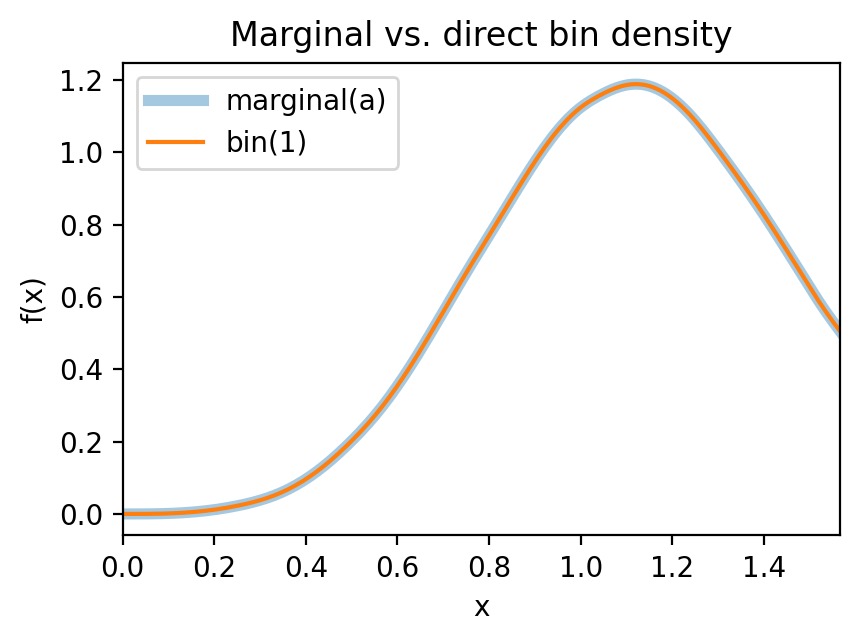

In [8]:
marg <- joint$marginal("a")  # branch length of bin 1 (singletons)
cat(sprintf("marginal mean = %.4f   (bin 1 mean = %.4f)\n", marg$mean, coal$sfs$bin(1L)$mean))

render_fn(function(f) {
    res <- plt$subplots(); ax <- res[[2]]
    marg$pdf$plot(ax = ax, show = FALSE, label = "marginal(a)", lw = 4, alpha = 0.4)
    coal$sfs$bin(1L)$pdf$plot(ax = ax, show = FALSE, label = "bin(1)",
                              title = "Marginal vs. direct bin density", lw = 1.5)
    plt$savefig(f, dpi = 200, bbox_inches = "tight"); plt$close("all")
})

## Conditional distributions

{meth}`JointRewardDistribution.conditional <phasegen.distributions.JointRewardDistribution.conditional>` gives the 1D distribution of one reward given the other equals a fixed value. Because the two rewards are negatively correlated, the doubleton length shifts left as the conditioning singleton length grows. Conditioning on a *short* singleton branch leaves the doubleton length bimodal, reflecting whether lineages coalesced during or after the bottleneck; conditioning on a *long* one collapses it to a single mode.

In [9]:
cat("E[R_b | R_a = v]:\n")
for (v in c(0.4, 0.9, 1.4)) {
    cat(sprintf("  v = %.1f:  %.3f\n", v, joint$conditional("a", v)$mean))
}

E[R_b | R_a = v]:


  v = 0.4:  0.461
  v = 0.9:  0.363
  v = 1.4:  0.271


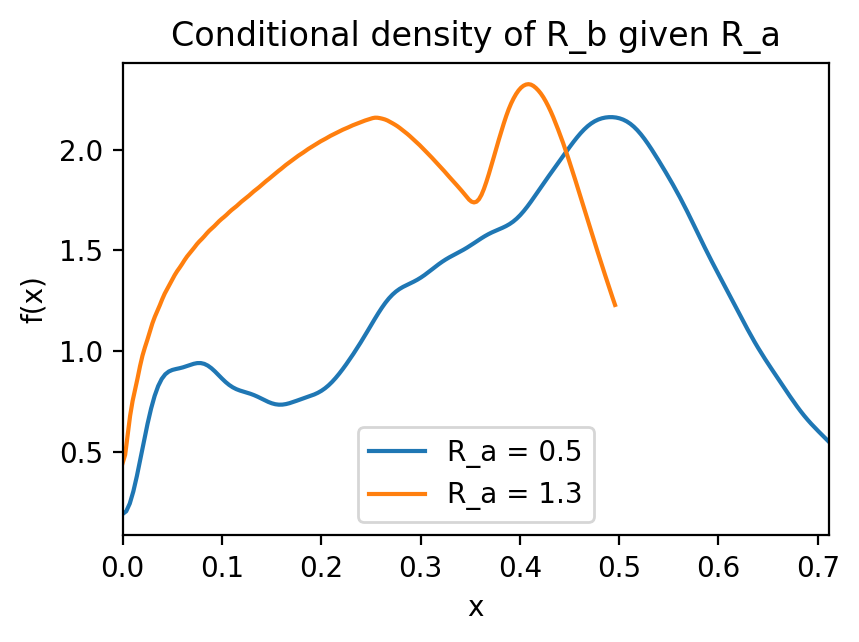

In [10]:
render_fn(function(f) {
    res <- plt$subplots(); ax <- res[[2]]
    for (v in c(0.5, 1.3)) {
        joint$conditional("a", v)$pdf$plot(ax = ax, show = FALSE, label = sprintf("R_a = %.1f", v),
                                           title = "Conditional density of R_b given R_a")
    }
    plt$savefig(f, dpi = 200, bbox_inches = "tight"); plt$close("all")
})

## Checking against the sampler

Every one of these objects has an empirical counterpart from {meth}`PhaseTypeDistribution.to_empirical <phasegen.distributions.PhaseTypeDistribution.to_empirical>` (see {doc}`Empirical distributions <empirical_distributions>`), drawn from the same model by Monte Carlo, with the empirical {meth}`EmpiricalPhaseTypeSFSDistribution.joint_distribution <phasegen.distributions.EmpiricalPhaseTypeSFSDistribution.joint_distribution>` exposing the matching {meth}`EmpiricalJointDistribution.marginal <phasegen.distributions.EmpiricalJointDistribution.marginal>` and {meth}`EmpiricalJointDistribution.conditional <phasegen.distributions.EmpiricalJointDistribution.conditional>`. This independently validates the exact results, which is valuable because the Laplace-transform inversion can lose precision for extreme demographies. The sampled conditional is only approximate, since it is estimated by restricting the unconditioned sample to a narrow window around the conditioning value rather than drawn from the conditional law directly, but it is close enough to confirm the exact densities that coincide with it below.

correlation:  exact -0.307   sampled -0.307


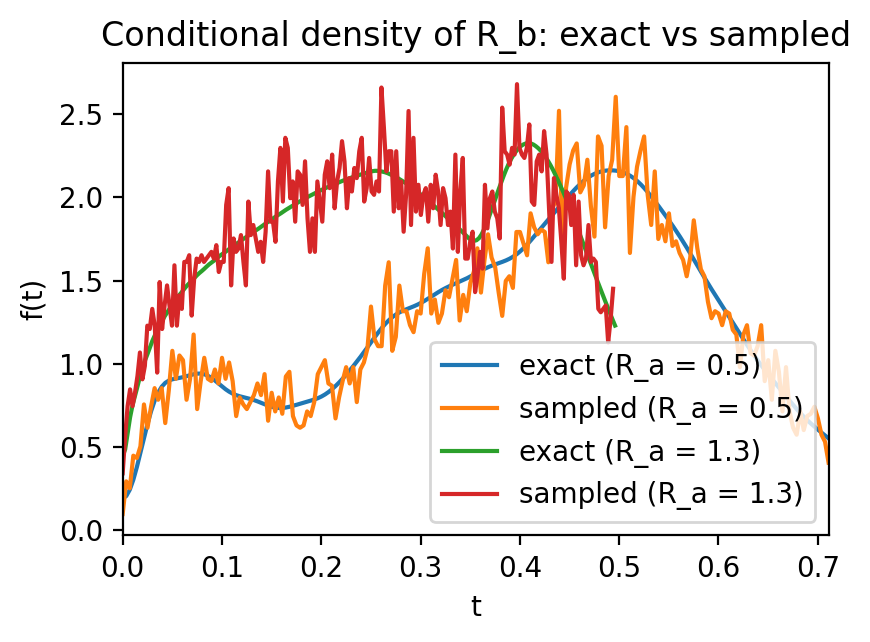

In [11]:
emp <- coal$sfs$to_empirical(1000000L)$joint_distribution(1L, 2L)
cat(sprintf("correlation:  exact %+.3f   sampled %+.3f\n", joint$corr(), emp$corr()))

render_fn(function(f) {
    res <- plt$subplots(); ax <- res[[2]]
    for (v in c(0.5, 1.3)) {
        joint$conditional("a", v)$pdf$plot(ax = ax, show = FALSE, label = sprintf("exact (R_a = %.1f)", v))
        emp$conditional("a", v)$pdf$plot(ax = ax, show = FALSE, label = sprintf("sampled (R_a = %.1f)", v),
                                         title = "Conditional density of R_b: exact vs sampled")
    }
    plt$savefig(f, dpi = 200, bbox_inches = "tight"); plt$close("all")
})